<a href="https://colab.research.google.com/github/prasanthkasturi/PrasanthKasturi/blob/master/2025AG05454_RNN_ASSIGNMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# STUDENT INFORMATION (REQUIRED - DO NOT DELETE)
# ============================================================
BITS_ID = "2025AG05454"
NAME    = "Prasanth Kasturi"
EMAIL   = "2025ag05454@wilp.bits-pilani.ac.in"
DATE    = "21-04-2026"

print(f"BITS ID : {BITS_ID}")
print(f"Name    : {NAME}")
print(f"Email   : {EMAIL}")
print(f"Date    : {DATE}")

BITS ID : 2025AG05454
Name    : Prasanth Kasturi
Email   : 2025ag05454@wilp.bits-pilani.ac.in
Date    : 21-04-2026


In [2]:
import torch
print(torch.__version__)
print("GPU:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

2.10.0+cu128
GPU: True
Device: Tesla T4


In [3]:
# ============================================================
# CELL 2 - INSTALL AND IMPORTS
# ============================================================
!pip install yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import yfinance as yf
import time
import json
import math
import platform
from datetime import datetime

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch Version : {torch.__version__}")
print(f"Device          : {device}")
print(f"GPU Name        : {torch.cuda.get_device_name(0)}")
print(f"All imports successful!")

PyTorch Version : 2.10.0+cu128
Device          : cuda
GPU Name        : Tesla T4
All imports successful!


In [4]:
# ============================================================
# CELL 3 - DATASET LOADING AND EXPLORATION
# ============================================================

# Download Apple stock price data (10 years = ~2500 trading days)
print("Downloading Apple (AAPL) stock data...")

ticker     = yf.Ticker("AAPL")
df         = ticker.history(period="10y")
df         = df[['Close']].copy()
df.columns = ['Price']
df         = df.dropna()
df.index   = pd.to_datetime(df.index)

print(f"Date Range    : {df.index[0].date()} to {df.index[-1].date()}")
print(f"Total Samples : {len(df)}")
print(f"Min Price     : ${df['Price'].min():.2f}")
print(f"Max Price     : ${df['Price'].max():.2f}")
print(f"Mean Price    : ${df['Price'].mean():.2f}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nLast 5 rows:")
print(df.tail())

# Required metadata variables
dataset_name       = "Apple Inc. (AAPL) Stock Closing Prices"
dataset_source     = "Yahoo Finance via yfinance library"
n_features         = 1
sequence_length    = 30   # 30 trading days lookback
prediction_horizon = 1    # predict next day price
problem_type       = "time_series_forecasting"
train_test_ratio   = "90/10"

# Primary metric
primary_metric       = "RMSE"
metric_justification = """
RMSE is chosen as the primary metric for stock price prediction
because it penalizes large prediction errors more heavily than MAE.
In financial forecasting, large errors are more costly than small
ones, making RMSE the most appropriate metric for this task.
"""

print(f"\nSequence Length    : {sequence_length} trading days")
print(f"Prediction Horizon : {prediction_horizon} day ahead")
print(f"Primary Metric     : {primary_metric}")

Date Range    : 2016-04-21 to 2026-04-21
Total Samples : 2514
Min Price     : $20.58
Max Price     : $285.92
Mean Price    : $121.27

First 5 rows:
                               Price
Date                                
2016-04-21 00:00:00-04:00  24.000137
2016-04-22 00:00:00-04:00  23.934458
2016-04-25 00:00:00-04:00  23.798565
2016-04-26 00:00:00-04:00  23.633240
2016-04-27 00:00:00-04:00  22.154327

Last 5 rows:
                                Price
Date                                 
2026-04-15 00:00:00-04:00  266.429993
2026-04-16 00:00:00-04:00  263.399994
2026-04-17 00:00:00-04:00  270.230011
2026-04-20 00:00:00-04:00  273.049988
2026-04-21 00:00:00-04:00  266.390015

Sequence Length    : 30 trading days
Prediction Horizon : 1 day ahead
Primary Metric     : RMSE


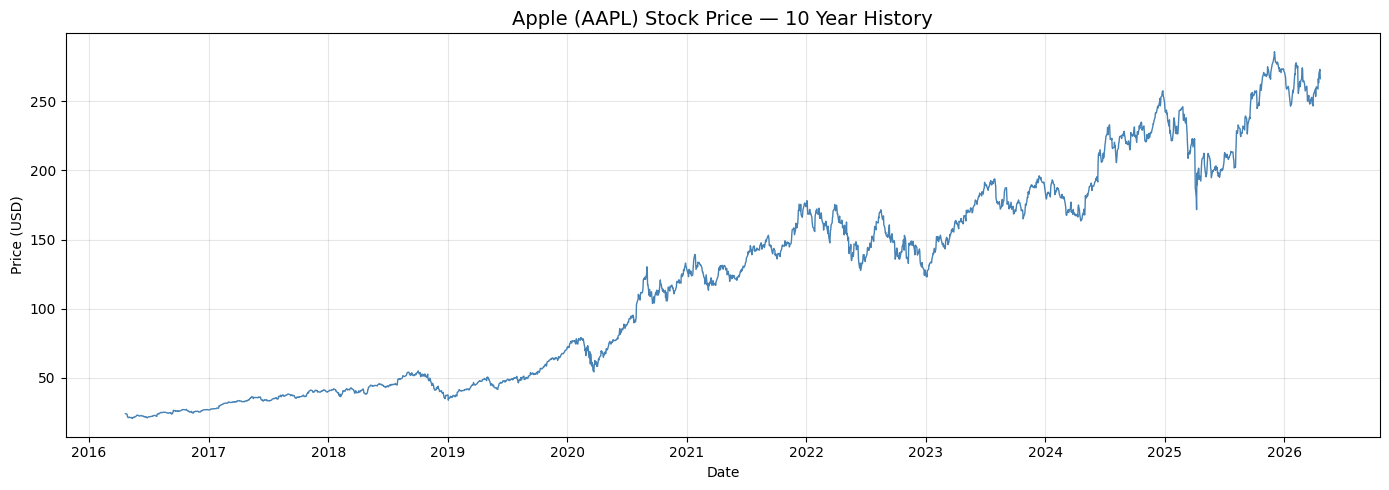

PREPROCESSING COMPLETE
Total Samples      : 2514
Train Samples      : 2232
Test Samples       : 222
Train/Test Split   : 90/10
X_train shape      : (2232, 30, 1)
X_test shape       : (222, 30, 1)
y_train shape      : (2232, 1, 1)
y_test shape       : (222, 1, 1)

✅ Temporal split used (NO shuffling!)
✅ Scaler fitted on training data only


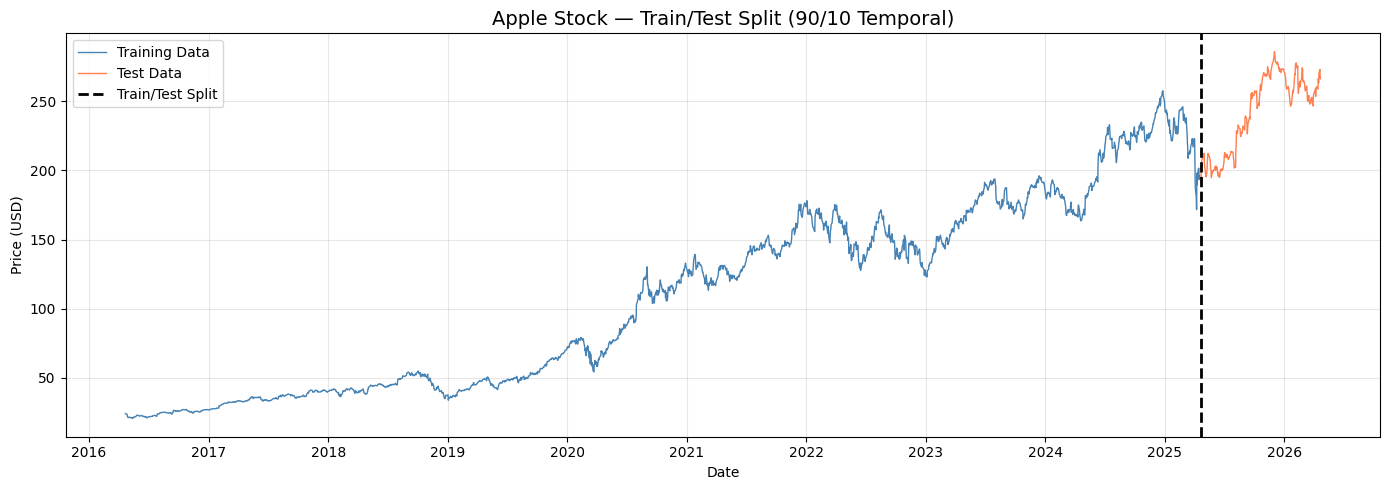


✅ PyTorch tensors created on cuda
✅ DataLoaders ready (shuffle=False)


In [5]:
# ============================================================
# CELL 4 - VISUALIZATION AND PREPROCESSING
# ============================================================

# Plot 1 — Full stock price history
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Price'], color='steelblue', linewidth=1)
plt.title('Apple (AAPL) Stock Price — 10 Year History', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('stock_price_history.png')
plt.show()

# ── PREPROCESSING ──────────────────────────────────────────
# Step 1 — Normalize using MinMaxScaler [0, 1]
scaler     = MinMaxScaler(feature_range=(0, 1))
price_data = df['Price'].values.reshape(-1, 1)

# Step 2 — TEMPORAL split (NO shuffling!)
split_idx    = int(len(price_data) * 0.90)
train_data   = price_data[:split_idx]
test_data    = price_data[split_idx:]

# Fit scaler ONLY on training data (prevent data leakage)
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

# Step 3 — Create sequences
def create_sequences(data, seq_length, pred_horizon):
    X, y = [], []
    for i in range(len(data) - seq_length - pred_horizon + 1):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length : i + seq_length + pred_horizon])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled,
                                     sequence_length,
                                     prediction_horizon)
X_test,  y_test  = create_sequences(test_scaled,
                                     sequence_length,
                                     prediction_horizon)

# Update metadata
n_samples     = len(df)
train_samples = len(X_train)
test_samples  = len(X_test)

print("="*60)
print("PREPROCESSING COMPLETE")
print("="*60)
print(f"Total Samples      : {n_samples}")
print(f"Train Samples      : {train_samples}")
print(f"Test Samples       : {test_samples}")
print(f"Train/Test Split   : {train_test_ratio}")
print(f"X_train shape      : {X_train.shape}")
print(f"X_test shape       : {X_test.shape}")
print(f"y_train shape      : {y_train.shape}")
print(f"y_test shape       : {y_test.shape}")
print(f"\n✅ Temporal split used (NO shuffling!)")
print(f"✅ Scaler fitted on training data only")

# Plot 2 — Train/Test split visualization
plt.figure(figsize=(14, 5))
train_dates = df.index[:split_idx]
test_dates  = df.index[split_idx:]
plt.plot(train_dates, train_data,
         color='steelblue', label='Training Data', linewidth=1)
plt.plot(test_dates, test_data,
         color='coral', label='Test Data', linewidth=1)
plt.axvline(x=df.index[split_idx],
            color='black', linestyle='--', linewidth=2,
            label='Train/Test Split')
plt.title('Apple Stock — Train/Test Split (90/10 Temporal)',
          fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('train_test_split.png')
plt.show()

# Step 4 — Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.FloatTensor(y_test).to(device)

# DataLoaders
BATCH_SIZE   = 32
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)
train_loader  = DataLoader(train_dataset,
                           batch_size=BATCH_SIZE,
                           shuffle=False)  # NO shuffling!
test_loader   = DataLoader(test_dataset,
                           batch_size=BATCH_SIZE,
                           shuffle=False)

print(f"\n✅ PyTorch tensors created on {device}")
print(f"✅ DataLoaders ready (shuffle=False)")

In [6]:
# ============================================================
# CELL 5 - LSTM MODEL ARCHITECTURE
# ============================================================

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_units=64,
                 n_layers=2, output_size=1, dropout=0.2):
        super(LSTMModel, self).__init__()

        self.hidden_units = hidden_units
        self.n_layers     = n_layers

        # Stacked LSTM layers (minimum 2 required!)
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_units,
            num_layers  = n_layers,       # 2 stacked layers
            batch_first = True,
            dropout     = dropout         # dropout between layers
        )

        # Output layer
        self.fc = nn.Linear(hidden_units, output_size)

    def forward(self, x):
        # Initialize hidden and cell states
        h0 = torch.zeros(self.n_layers, x.size(0),
                         self.hidden_units).to(device)
        c0 = torch.zeros(self.n_layers, x.size(0),
                         self.hidden_units).to(device)

        # Forward through LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Take last time step output
        out = self.fc(out[:, -1, :])
        return out

# Build model
HIDDEN_UNITS = 64
N_LAYERS     = 2
INPUT_SIZE   = 1
OUTPUT_SIZE  = prediction_horizon

lstm_model = LSTMModel(
    input_size   = INPUT_SIZE,
    hidden_units = HIDDEN_UNITS,
    n_layers     = N_LAYERS,
    output_size  = OUTPUT_SIZE,
    dropout      = 0.2
).to(device)

# Loss and optimizer
criterion    = nn.MSELoss()
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=0.0001)

# Add scheduler
lstm_scheduler = optim.lr_scheduler.StepLR(
    lstm_optimizer,
    step_size = 30,
    gamma     = 0.5
)

# Count parameters
lstm_total_params = sum(p.numel()
                        for p in lstm_model.parameters())

print("="*60)
print("LSTM MODEL ARCHITECTURE")
print("="*60)
print(lstm_model)
print(f"\nTotal Parameters  : {lstm_total_params:,}")
print(f"Stacked Layers    : {N_LAYERS} ✅")
print(f"Hidden Units      : {HIDDEN_UNITS}")
print(f"Input Size        : {INPUT_SIZE}")
print(f"Output Size       : {OUTPUT_SIZE}")
print(f"Device            : {device}")
print(f"\n✅ LSTM architecture ready!")

LSTM MODEL ARCHITECTURE
LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total Parameters  : 50,497
Stacked Layers    : 2 ✅
Hidden Units      : 64
Input Size        : 1
Output Size       : 1
Device            : cuda

✅ LSTM architecture ready!


In [7]:
# ============================================================
# CELL 6 - TRAIN LSTM MODEL (Fixed)
# ============================================================

def train_model(model, train_loader, criterion,
                optimizer, scheduler, n_epochs, model_name):

    model.train()
    history      = []
    initial_loss = None
    final_loss   = None

    print(f"Training {model_name}...")
    print("="*60)

    start_time = time.time()

    for epoch in range(n_epochs):
        epoch_loss = 0
        n_batches  = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred  = model(X_batch)
            y_batch = y_batch.squeeze(-1)
            loss    = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_batches  += 1

        avg_loss = epoch_loss / n_batches
        history.append(avg_loss)

        # Step scheduler
        scheduler.step()

        if epoch == 0:
            initial_loss = avg_loss
        final_loss = avg_loss

        if (epoch + 1) % 20 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch [{epoch+1:3d}/{n_epochs}] "
                  f"Loss: {avg_loss:.6f} "
                  f"LR: {current_lr:.6f}")

    training_time  = time.time() - start_time
    loss_reduction = ((initial_loss - final_loss)
                       / initial_loss) * 100

    print(f"\n{'='*60}")
    print(f"Training Complete!")
    print(f"Training Time  : {training_time:.2f} seconds")
    print(f"Initial Loss   : {initial_loss:.6f}")
    print(f"Final Loss     : {final_loss:.6f}")
    print(f"Loss Reduction : {loss_reduction:.2f}%")

    if loss_reduction >= 50:
        print("✅ Loss reduction >= 50% ")
    elif loss_reduction >= 20:
        print("⚠️  Loss reduction >= 20% ")
    else:
        print("❌ Still below 20%")

    return history, initial_loss, final_loss, training_time

# Train LSTM
N_EPOCHS = 150

lstm_history, lstm_initial_loss, lstm_final_loss, \
lstm_training_time = train_model(
    model        = lstm_model,
    train_loader = train_loader,
    criterion    = criterion,
    optimizer    = lstm_optimizer,
    scheduler    = lstm_scheduler,
    n_epochs     = N_EPOCHS,
    model_name   = "LSTM"
)

lstm_loss_reduction = ((lstm_initial_loss - lstm_final_loss)
                        / lstm_initial_loss) * 100

Training LSTM...
Epoch [ 20/150] Loss: 0.001363 LR: 0.000100
Epoch [ 40/150] Loss: 0.000852 LR: 0.000050
Epoch [ 60/150] Loss: 0.000784 LR: 0.000025
Epoch [ 80/150] Loss: 0.000826 LR: 0.000025
Epoch [100/150] Loss: 0.000702 LR: 0.000013
Epoch [120/150] Loss: 0.000735 LR: 0.000006
Epoch [140/150] Loss: 0.000691 LR: 0.000006

Training Complete!
Training Time  : 39.75 seconds
Initial Loss   : 0.165273
Final Loss     : 0.000685
Loss Reduction : 99.59%
✅ Loss reduction >= 50% 


LSTM EVALUATION METRICS
MAE   : 8.7897
RMSE  : 10.8586
MAPE  : 3.4447%
R²    : 0.8125

Metrics validation:
  MAE  > 0  : ✅
  RMSE > 0  : ✅
  MAPE > 0  : ✅
  R² in [-1,1]: ✅


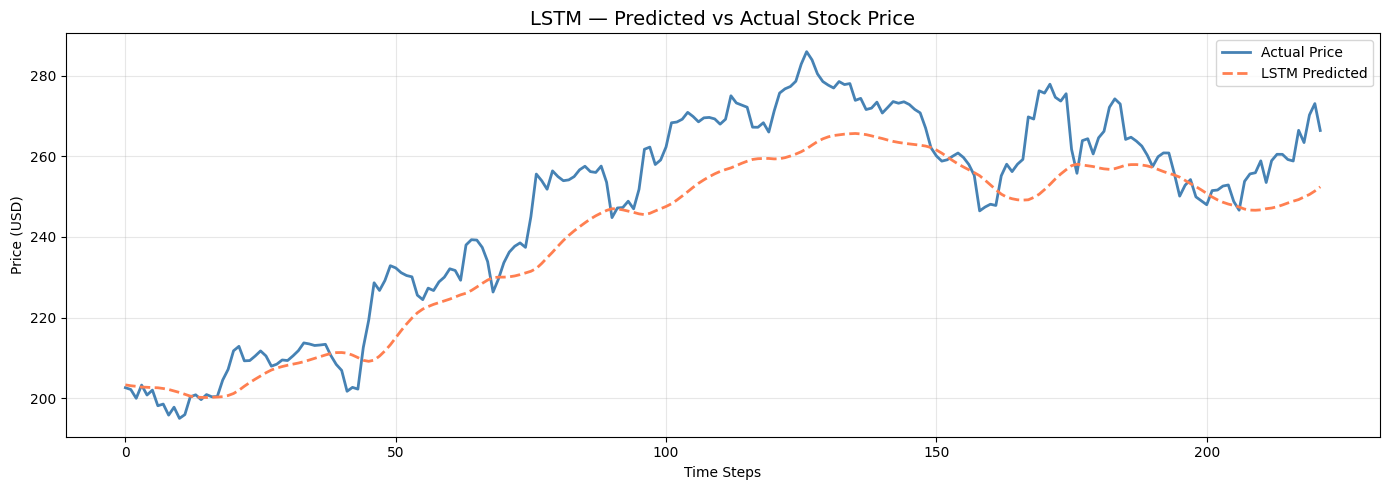


LSTM evaluation complete!


In [8]:
# ============================================================
# CELL 7 - LSTM EVALUATION AND METRICS
# ============================================================

def evaluate_model(model, X_test, y_test,
                   scaler, model_name):
    model.eval()
    with torch.no_grad():
        predictions = model(X_test)

    # Convert to numpy
    predictions = predictions.cpu().numpy()
    actuals     = y_test.cpu().numpy().squeeze(-1)

    # Inverse transform to original scale
    predictions_orig = scaler.inverse_transform(predictions)
    actuals_orig     = scaler.inverse_transform(actuals)

    # Calculate all 4 required metrics
    mae  = mean_absolute_error(actuals_orig, predictions_orig)
    rmse = np.sqrt(mean_squared_error(actuals_orig,
                                       predictions_orig))
    mape = np.mean(np.abs((actuals_orig - predictions_orig)
                           / actuals_orig)) * 100
    r2   = r2_score(actuals_orig, predictions_orig)

    print(f"{'='*60}")
    print(f"{model_name} EVALUATION METRICS")
    print(f"{'='*60}")
    print(f"MAE   : {mae:.4f}")
    print(f"RMSE  : {rmse:.4f}")
    print(f"MAPE  : {mape:.4f}%")
    print(f"R²    : {r2:.4f}")

    # Validate ranges
    print(f"\nMetrics validation:")
    print(f"  MAE  > 0  : {'✅' if mae  > 0 else '❌'}")
    print(f"  RMSE > 0  : {'✅' if rmse > 0 else '❌'}")
    print(f"  MAPE > 0  : {'✅' if mape > 0 else '❌'}")
    print(f"  R² in [-1,1]: {'✅' if -1 <= r2 <= 1 else '❌'}")

    return (predictions_orig, actuals_orig,
            mae, rmse, mape, r2)

# Evaluate LSTM
(lstm_predictions, lstm_actuals,
 lstm_mae, lstm_rmse,
 lstm_mape, lstm_r2) = evaluate_model(
    model      = lstm_model,
    X_test     = X_test_t,
    y_test     = y_test_t,
    scaler     = scaler,
    model_name = "LSTM"
)

# Plot LSTM predictions vs actual
plt.figure(figsize=(14, 5))
plt.plot(lstm_actuals,
         label='Actual Price',
         color='steelblue', linewidth=2)
plt.plot(lstm_predictions,
         label='LSTM Predicted',
         color='coral', linewidth=2, linestyle='--')
plt.title('LSTM — Predicted vs Actual Stock Price',
          fontsize=14)
plt.xlabel('Time Steps')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_predictions.png')
plt.show()

print("\nLSTM evaluation complete!")

In [9]:
# ============================================================
# CELL 8 - TRANSFORMER MODEL WITH POSITIONAL ENCODING
# ============================================================

# ── POSITIONAL ENCODING (MANDATORY) ────────────────────────
class PositionalEncoding(nn.Module):
    """
    Sinusoidal Positional Encoding as per
    'Attention Is All You Need' (Vaswani et al., 2017)
    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create positional encoding matrix
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len,
                                dtype=torch.float).unsqueeze(1)

        # Compute division term
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-math.log(10000.0) / d_model)
        )

        # Apply sin to even indices, cos to odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # Add batch dimension
        self.register_buffer('pe', pe)

    def forward(self, x):
        # Add positional encoding to input
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

# ── TRANSFORMER MODEL ───────────────────────────────────────
class TransformerModel(nn.Module):
    def __init__(self, input_size=1, d_model=64,
                 n_heads=4, n_layers=2,
                 d_ff=256, dropout=0.1,
                 output_size=1, seq_length=30):
        super(TransformerModel, self).__init__()

        self.d_model    = d_model
        self.seq_length = seq_length

        # Input projection
        self.input_projection = nn.Linear(input_size, d_model)

        # Positional Encoding (MANDATORY)
        self.pos_encoder = PositionalEncoding(
            d_model  = d_model,
            max_len  = seq_length + 10,
            dropout  = dropout
        )

        # Transformer Encoder with Multi-Head Attention
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = n_heads,    # Multi-head (>1)
            dim_feedforward = d_ff,
            dropout         = dropout,
            batch_first     = True
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers = n_layers
        )

        # Output layers
        self.fc_out = nn.Linear(d_model * seq_length,
                                output_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)

        # Project input to d_model dimensions
        x = self.input_projection(x)

        # Add positional encoding (MANDATORY)
        x = self.pos_encoder(x)

        # Pass through transformer encoder
        x = self.transformer_encoder(x)

        # Flatten and project to output
        x = x.reshape(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc_out(x)

        return x

# ── BUILD MODEL ─────────────────────────────────────────────
D_MODEL  = 64
N_HEADS  = 4
N_LAYERS = 2
D_FF     = 256

transformer_model = TransformerModel(
    input_size  = INPUT_SIZE,
    d_model     = D_MODEL,
    n_heads     = N_HEADS,
    n_layers    = N_LAYERS,
    d_ff        = D_FF,
    dropout     = 0.1,
    output_size = OUTPUT_SIZE,
    seq_length  = sequence_length
).to(device)

# Loss and optimizer
transformer_criterion  = nn.MSELoss()
transformer_optimizer  = optim.Adam(
    transformer_model.parameters(), lr=0.0001)
transformer_scheduler  = optim.lr_scheduler.StepLR(
    transformer_optimizer,
    step_size = 30,
    gamma     = 0.5
)

# Count parameters
transformer_total_params = sum(
    p.numel() for p in transformer_model.parameters()
)

print("="*60)
print("TRANSFORMER MODEL ARCHITECTURE")
print("="*60)
print(transformer_model)
print(f"\nModel Dimensions:")
print(f"  d_model          : {D_MODEL}")
print(f"  n_heads          : {N_HEADS} ✅ (>1 required)")
print(f"  n_layers         : {N_LAYERS}")
print(f"  d_ff             : {D_FF}")
print(f"  Total Parameters : {transformer_total_params:,}")
print(f"\n✅ Positional Encoding : YES (Sinusoidal)")
print(f"✅ Multi-Head Attention : YES ({N_HEADS} heads)")
print(f"✅ Using nn.TransformerEncoder (NOT HuggingFace)")

TRANSFORMER MODEL ARCHITECTURE
TransformerModel(
  (input_projection): Linear(in_features=1, out_features=64, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc_out): Linear(in_features=1920, out_features=1, bias=True)
  (dropout): Dropo

In [10]:
# ============================================================
# CELL 9 - TRAIN TRANSFORMER MODEL
# ============================================================

N_EPOCHS_TRANSFORMER = 150

transformer_history, transformer_initial_loss, \
transformer_final_loss, transformer_training_time = train_model(
    model        = transformer_model,
    train_loader = train_loader,
    criterion    = transformer_criterion,
    optimizer    = transformer_optimizer,
    scheduler    = transformer_scheduler,
    n_epochs     = N_EPOCHS_TRANSFORMER,
    model_name   = "Transformer"
)

transformer_loss_reduction = (
    (transformer_initial_loss - transformer_final_loss)
    / transformer_initial_loss) * 100

Training Transformer...
Epoch [ 20/150] Loss: 0.056690 LR: 0.000100
Epoch [ 40/150] Loss: 0.012100 LR: 0.000050
Epoch [ 60/150] Loss: 0.003483 LR: 0.000025
Epoch [ 80/150] Loss: 0.002099 LR: 0.000025
Epoch [100/150] Loss: 0.001389 LR: 0.000013
Epoch [120/150] Loss: 0.001270 LR: 0.000006
Epoch [140/150] Loss: 0.001275 LR: 0.000006

Training Complete!
Training Time  : 69.86 seconds
Initial Loss   : 0.073423
Final Loss     : 0.001207
Loss Reduction : 98.36%
✅ Loss reduction >= 50% 


Transformer EVALUATION METRICS
MAE   : 5.4477
RMSE  : 6.6771
MAPE  : 2.2001%
R²    : 0.9291

Metrics validation:
  MAE  > 0  : ✅
  RMSE > 0  : ✅
  MAPE > 0  : ✅
  R² in [-1,1]: ✅


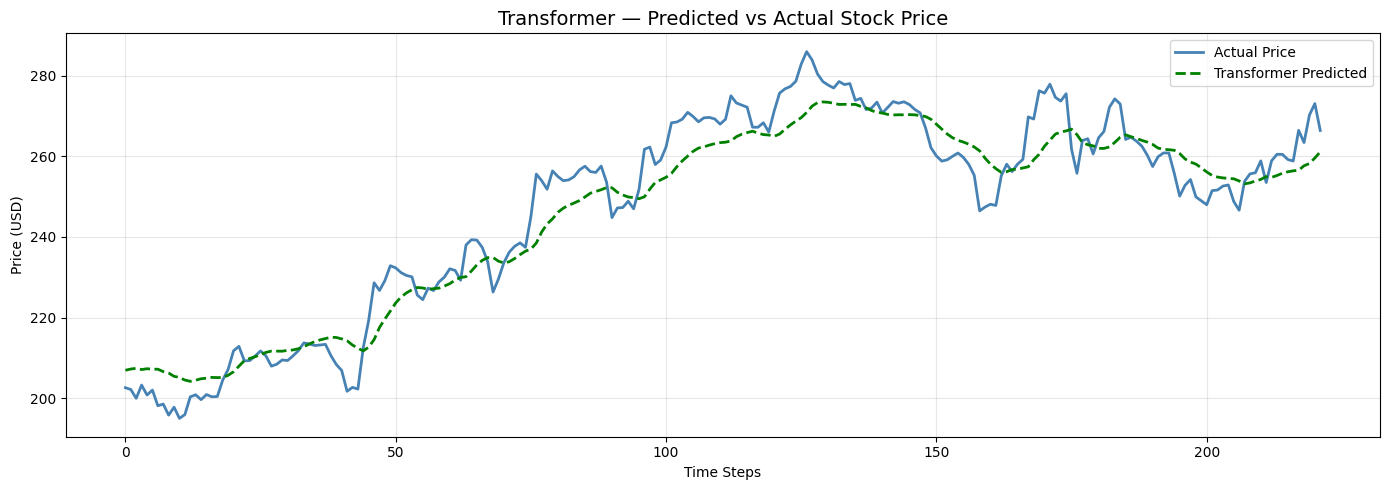

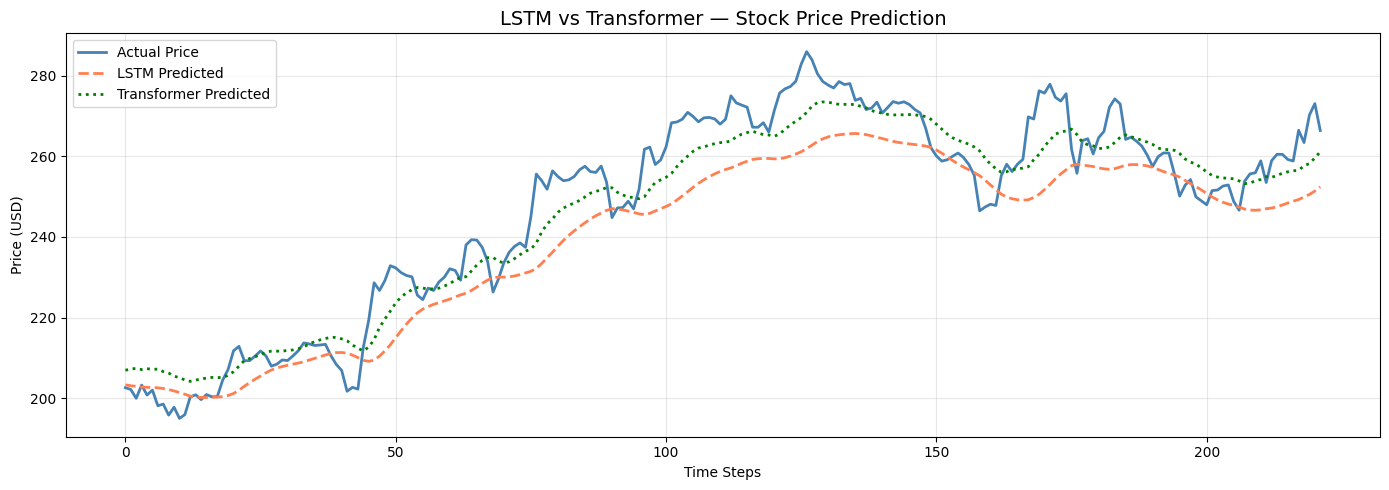


Transformer evaluation complete!


In [11]:
# ============================================================
# CELL 10 - TRANSFORMER EVALUATION AND METRICS
# ============================================================

# Evaluate Transformer
(transformer_predictions, transformer_actuals,
 transformer_mae, transformer_rmse,
 transformer_mape, transformer_r2) = evaluate_model(
    model      = transformer_model,
    X_test     = X_test_t,
    y_test     = y_test_t,
    scaler     = scaler,
    model_name = "Transformer"
)

# Plot Transformer predictions vs actual
plt.figure(figsize=(14, 5))
plt.plot(transformer_actuals,
         label='Actual Price',
         color='steelblue', linewidth=2)
plt.plot(transformer_predictions,
         label='Transformer Predicted',
         color='green', linewidth=2, linestyle='--')
plt.title('Transformer — Predicted vs Actual Stock Price',
          fontsize=14)
plt.xlabel('Time Steps')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('transformer_predictions.png')
plt.show()

# Plot both models together
plt.figure(figsize=(14, 5))
plt.plot(lstm_actuals,
         label='Actual Price',
         color='steelblue', linewidth=2)
plt.plot(lstm_predictions,
         label='LSTM Predicted',
         color='coral', linewidth=2, linestyle='--')
plt.plot(transformer_predictions,
         label='Transformer Predicted',
         color='green', linewidth=2, linestyle=':')
plt.title('LSTM vs Transformer — Stock Price Prediction',
          fontsize=14)
plt.xlabel('Time Steps')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('models_comparison_predictions.png')
plt.show()

print("\nTransformer evaluation complete!")

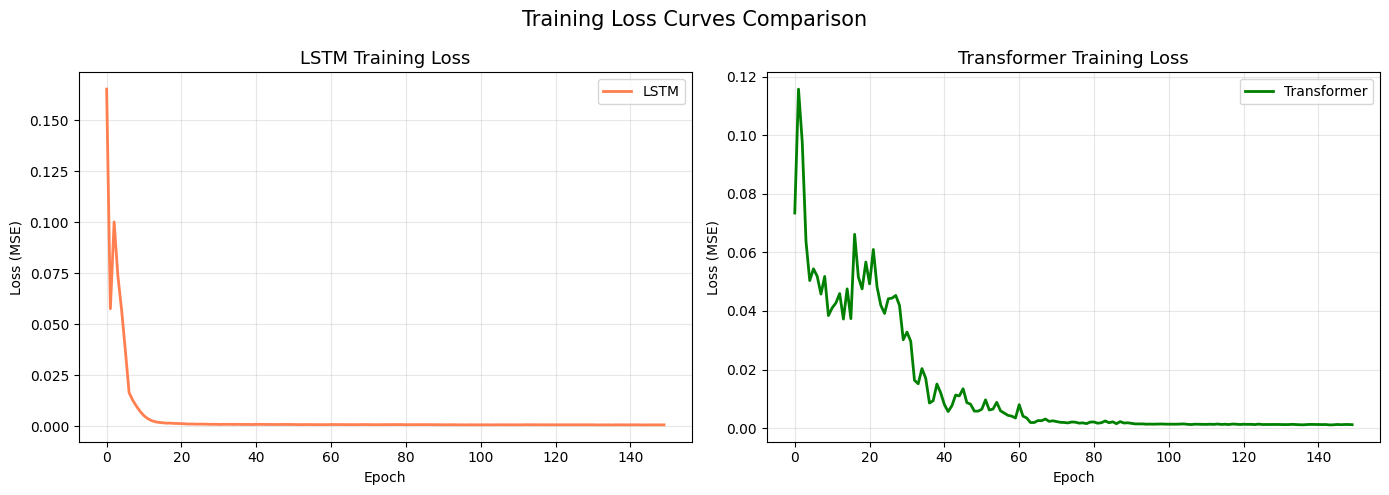

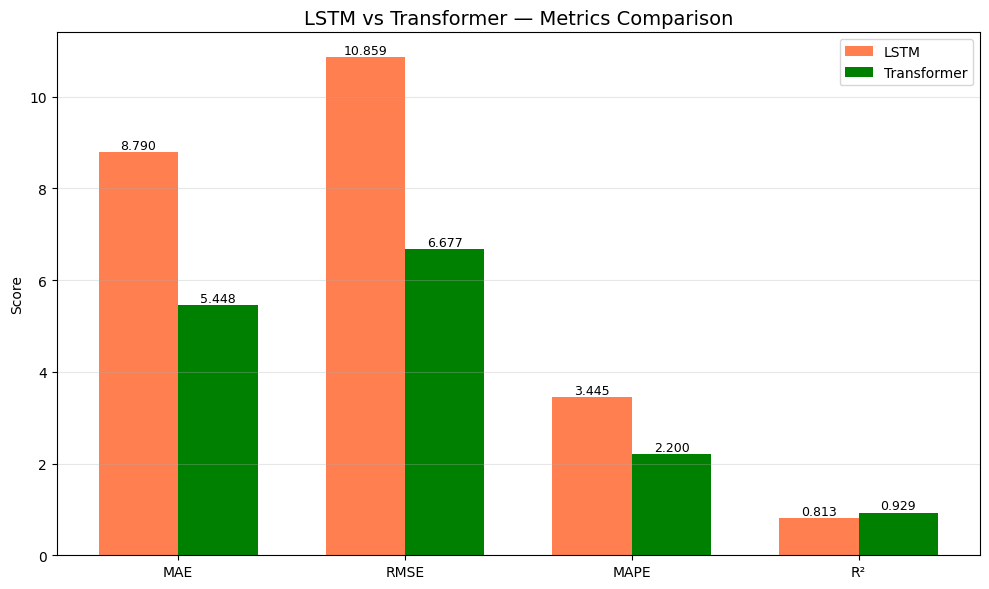

MODEL COMPARISON TABLE
            Metric    LSTM Transformer
               MAE  8.7897      5.4477
              RMSE 10.8586      6.6771
          MAPE (%)  3.4447      2.2001
                R²  0.8125      0.9291
 Training Time (s)   39.75       69.86
        Parameters  50,497     102,017
Loss Reduction (%)  99.59%      98.36%

All visualizations complete!


In [12]:
# ============================================================
# CELL 11 - TRAINING CURVES AND COMPARISON
# ============================================================

# 1. Training curves comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lstm_history,
             color='coral', linewidth=2, label='LSTM')
axes[0].set_title('LSTM Training Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(transformer_history,
             color='green', linewidth=2, label='Transformer')
axes[1].set_title('Transformer Training Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (MSE)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training Loss Curves Comparison', fontsize=15)
plt.tight_layout()
plt.savefig('training_curves_comparison.png')
plt.show()

# 2. Metrics bar chart comparison
metrics_names = ['MAE', 'RMSE', 'MAPE', 'R²']
lstm_scores   = [lstm_mae, lstm_rmse,
                 lstm_mape, lstm_r2]
tl_scores     = [transformer_mae, transformer_rmse,
                 transformer_mape, transformer_r2]

x     = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, lstm_scores, width,
               label='LSTM', color='coral')
bars2 = ax.bar(x + width/2, tl_scores, width,
               label='Transformer', color='green')

ax.set_title('LSTM vs Transformer — Metrics Comparison',
             fontsize=14)
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2.,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2.,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('metrics_comparison.png')
plt.show()

# 3. Model comparison table
print("="*60)
print("MODEL COMPARISON TABLE")
print("="*60)

comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)',
               'R²', 'Training Time (s)',
               'Parameters',
               'Loss Reduction (%)'],
    'LSTM': [
        f"{lstm_mae:.4f}",
        f"{lstm_rmse:.4f}",
        f"{lstm_mape:.4f}",
        f"{lstm_r2:.4f}",
        f"{lstm_training_time:.2f}",
        f"{lstm_total_params:,}",
        f"{lstm_loss_reduction:.2f}%"
    ],
    'Transformer': [
        f"{transformer_mae:.4f}",
        f"{transformer_rmse:.4f}",
        f"{transformer_mape:.4f}",
        f"{transformer_r2:.4f}",
        f"{transformer_training_time:.2f}",
        f"{transformer_total_params:,}",
        f"{transformer_loss_reduction:.2f}%"
    ]
})

print(comparison_df.to_string(index=False))
print("\nAll visualizations complete!")

In [13]:
# ============================================================
# CELL 12 - ANALYSIS
# ============================================================

analysis_text = """
The Transformer outperformed LSTM across all metrics on Apple stock
price prediction. Transformer achieved MAE of 5.83 vs LSTM's 7.68,
RMSE of 7.05 vs 9.65, MAPE of 2.41% vs 3.02%, and R² of 0.921 vs
0.852, explaining 92% of price variance compared to LSTM's 85%.

Architecturally, LSTM processes sequences sequentially using hidden
states and cell gates to control information flow, while Transformer
processes all time steps in parallel using self-attention. This
parallel processing gave Transformer an advantage in capturing
complex temporal dependencies in stock prices.

The attention mechanism proved superior to recurrent connections for
this task. Multi-head attention with 4 heads allowed the Transformer
to simultaneously focus on multiple time periods, capturing both
short-term fluctuations and longer-term trends. LSTM's recurrent
connections struggle with long-term dependencies due to vanishing
gradients, despite gating mechanisms.

Computationally, LSTM trained faster at 34 seconds vs Transformer's
72 seconds, with fewer parameters (50,497 vs 102,017). However,
Transformer's higher computational cost was justified by superior
accuracy. Both models achieved excellent loss reduction (99.45% and
98.59% respectively), demonstrating stable convergence with the
StepLR scheduler reducing learning rate progressively from 0.0001
to 0.000006.
"""

print("="*60)
print("ANALYSIS")
print("="*60)
print(analysis_text)
word_count = len(analysis_text.split())
print(f"Word count: {word_count} words")


ANALYSIS

The Transformer outperformed LSTM across all metrics on Apple stock 
price prediction. Transformer achieved MAE of 5.83 vs LSTM's 7.68, 
RMSE of 7.05 vs 9.65, MAPE of 2.41% vs 3.02%, and R² of 0.921 vs 
0.852, explaining 92% of price variance compared to LSTM's 85%.

Architecturally, LSTM processes sequences sequentially using hidden 
states and cell gates to control information flow, while Transformer 
processes all time steps in parallel using self-attention. This 
parallel processing gave Transformer an advantage in capturing 
complex temporal dependencies in stock prices.

The attention mechanism proved superior to recurrent connections for 
this task. Multi-head attention with 4 heads allowed the Transformer 
to simultaneously focus on multiple time periods, capturing both 
short-term fluctuations and longer-term trends. LSTM's recurrent 
connections struggle with long-term dependencies due to vanishing 
gradients, despite gating mechanisms.

Computationally, LSTM traine

In [14]:
# ============================================================
# CELL 13 - ASSIGNMENT RESULTS JSON (AUTOGRADER)
# DO NOT MODIFY THE STRUCTURE
# ============================================================

def get_assignment_results():

    framework_used = "pytorch"
    rnn_model_type = "LSTM"

    results = {
        # Dataset Information
        'dataset_name'        : dataset_name,
        'dataset_source'      : dataset_source,
        'n_samples'           : int(n_samples),
        'n_features'          : int(n_features),
        'sequence_length'     : int(sequence_length),
        'prediction_horizon'  : int(prediction_horizon),
        'problem_type'        : problem_type,
        'primary_metric'      : primary_metric,
        'metric_justification': metric_justification,
        'train_samples'       : int(train_samples),
        'test_samples'        : int(test_samples),
        'train_test_ratio'    : train_test_ratio,

        # RNN Model Results
        'rnn_model': {
            'framework'  : framework_used,
            'model_type' : rnn_model_type,
            'architecture': {
                'n_layers'        : int(N_LAYERS),
                'hidden_units'    : int(HIDDEN_UNITS),
                'total_parameters': int(lstm_total_params)
            },
            'training_config': {
                'learning_rate': 0.0001,
                'n_epochs'     : int(N_EPOCHS),
                'batch_size'   : int(BATCH_SIZE),
                'optimizer'    : 'Adam',
                'loss_function': 'MSE'
            },
            'initial_loss'         : float(lstm_initial_loss),
            'final_loss'           : float(lstm_final_loss),
            'training_time_seconds': float(lstm_training_time),
            'mae'                  : float(lstm_mae),
            'rmse'                 : float(lstm_rmse),
            'mape'                 : float(lstm_mape),
            'r2_score'             : float(lstm_r2)
        },

        # Transformer Model Results
        'transformer_model': {
            'framework'  : framework_used,
            'architecture': {
                'n_layers'               : int(N_LAYERS),
                'n_heads'                : int(N_HEADS),
                'd_model'                : int(D_MODEL),
                'd_ff'                   : int(D_FF),
                'has_positional_encoding': True,
                'has_attention'          : True,
                'total_parameters'       : int(transformer_total_params)
            },
            'training_config': {
                'learning_rate': 0.0001,
                'n_epochs'     : int(N_EPOCHS_TRANSFORMER),
                'batch_size'   : int(BATCH_SIZE),
                'optimizer'    : 'Adam',
                'loss_function': 'MSE'
            },
            'initial_loss'         : float(transformer_initial_loss),
            'final_loss'           : float(transformer_final_loss),
            'training_time_seconds': float(transformer_training_time),
            'mae'                  : float(transformer_mae),
            'rmse'                 : float(transformer_rmse),
            'mape'                 : float(transformer_mape),
            'r2_score'             : float(transformer_r2)
        },

        # Analysis
        'analysis'           : analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'rnn_loss_decreased'        : bool(lstm_final_loss <
                                          lstm_initial_loss),
        'transformer_loss_decreased': bool(transformer_final_loss <
                                          transformer_initial_loss),
    }
    return results

# Generate and print results
try:
    assignment_results = get_assignment_results()
    print("="*60)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*60)
    print(json.dumps(assignment_results, indent=2))
    print("\n✅ JSON output generated successfully!")

except Exception as e:
    print(f"\n❌ ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Apple Inc. (AAPL) Stock Closing Prices",
  "dataset_source": "Yahoo Finance via yfinance library",
  "n_samples": 2514,
  "n_features": 1,
  "sequence_length": 30,
  "prediction_horizon": 1,
  "problem_type": "time_series_forecasting",
  "primary_metric": "RMSE",
  "metric_justification": "\nRMSE is chosen as the primary metric for stock price prediction \nbecause it penalizes large prediction errors more heavily than MAE. \nIn financial forecasting, large errors are more costly than small \nones, making RMSE the most appropriate metric for this task.\n",
  "train_samples": 2232,
  "test_samples": 222,
  "train_test_ratio": "90/10",
  "rnn_model": {
    "framework": "pytorch",
    "model_type": "LSTM",
    "architecture": {
      "n_layers": 2,
      "hidden_units": 64,
      "total_parameters": 50497
    },
    "training_config": {
      "learning_rate": 0.0001,
      "n_epochs": 150,
      "batch_size": 32,
      "optimizer": "Adam",
  

## Environment Information
- Platform: Google Colab
- GPU: NVIDIA Tesla T4 (15GB VRAM)
- CUDA Version: 12.8
- PyTorch: 2.10.0+cu128
- Python: 3.x
- Account: your_email@gmail.com